# Лабораторный практикум по курсу «Синтез Речи», Университет ИТМО, 2026
**Лабораторная работа №2.** Просодика

**Цель работы**: Разработка модуля прогнозирования мест и длительности пауз по тексту на русском языке

**Краткое описание:** В рамках настоящей работы необходимо ознакомиться с пословной сегментацией данных из дейтасета "RUSLAN", изучить распределение длительности пауз в наборе данных, провести анализ качества сегментации, и разработать модуль предсказания мест и длительности пауз по тексту.

## 0. Импорты библиотек

In [ ]:
import os
import re
import csv
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import subprocess, sys
from praatio import textgrid
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [57]:
COLOR_BEIGE = '#D4B896'
COLOR_BLUE  = '#7EA6C7'

## 1. Подготовка данных

К классической MFA разметке предлагается добавить шумоочистку:
- **Нормализация** знаков препинания;
- **Микро-паузы**: только при SIL ≥ 30 мс.;
- **Шумные предложения**: убираются предложения <3 слов и с плотностью пауз >40%.

Изначально в задании предлагалось удалять предложения, где MFA не нашёл ни одной паузы. Но при тестировании этот фильтр удалял 38% данных (8265 из 21622 предложений), что нарушало баланс классов: доля пауз росла, а модель начинала предсказывать паузы. Отключение этого фильтра (MIN_PAUSE_DENSITY = -1.0) даёт лучший F1. В финальной версии применяются только фильтры, перечисленные выше.

In [58]:
result = subprocess.run(
    [sys.executable, 'prepare_training_data.py'],
    capture_output=True, text=True, cwd='.'
)

out = result.stdout
start = out.find('До фильтрации:')
if start != -1:
    out = out[start:]

print(out)
if result.returncode != 0:
    print('STDERR:', result.stderr)
    raise RuntimeError(f'prepare_training_data.py failed with code {result.returncode}')

До фильтрации: 21622 предложений, 247533 токенов

Фильтрация предложений:
  too_short  (<3 слов): 1149
  too_dense  (>0.4 пауз):  1084
  kept:                             19389
После фильтрации: 19389 предложений, 234016 токенов

Итоговая статистика:
  train: 187105 токенов, доля пауз: 0.1883
  test:  46911 токенов, доля пауз: 0.1867

Saved to data/RUSLAN_pause_metadata.csv



## 2. Разведочный анализ данных

### 2.1. Общая статистика корпуса

In [59]:
df = pd.read_csv('data/RUSLAN_pause_metadata.csv', sep='|', quoting=csv.QUOTE_NONE)

print(f"Всего строк: {len(df)}")
print(f"Колонки: {df.columns.tolist()}")
df.head()

Всего строк: 234016
Колонки: ['label', 'duration', 'id', 'label_raw', 'is_last_word', 'is_pause_after', 'pause_duration', 'set']


,label,duration,id,label_raw,is_last_word,is_pause_after,pause_duration,set
0,с,0.11,000000_RUSLAN,С,0,0,0.0,test
1,тревожным,0.58,000000_RUSLAN,тревожным,0,0,0.0,test
2,чувством,0.62,000000_RUSLAN,чувством,0,0,0.0,test
3,берусь,0.39,000000_RUSLAN,берусь,0,0,0.0,test
4,я,0.09,000000_RUSLAN,я,0,0,0.0,test


In [60]:
print(f"Уникальных предложений (id): {df['id'].nunique()}")
print(f"Уникальных слов (label): {df['label'].nunique()}")

print(f"\nРазбиение train/test:")
print(f"  train: {df['set'].value_counts()['train']} ({df['set'].value_counts(normalize=True)['train']*100:.1f}%)")
print(f"  test:  {df['set'].value_counts()['test']} ({df['set'].value_counts(normalize=True)['test']*100:.1f}%)")

Уникальных предложений (id): 19389
Уникальных слов (label): 45369

Разбиение train/test:
  train: 187105 (80.0%)
  test:  46911 (20.0%)


In [61]:
print(f"\nДоля пауз (is_pause_after):")
print(f"  С паузой:    {df['is_pause_after'].sum()} ({df['is_pause_after'].mean()*100:.2f}%)")
print(f"  Без паузы:   {len(df) - df['is_pause_after'].sum()} ({(1-df['is_pause_after'].mean())*100:.2f}%)")


Доля пауз (is_pause_after):
  С паузой:    43986 (18.80%)
  Без паузы:   190030 (81.20%)


### 2.2. Длительности слов и пауз

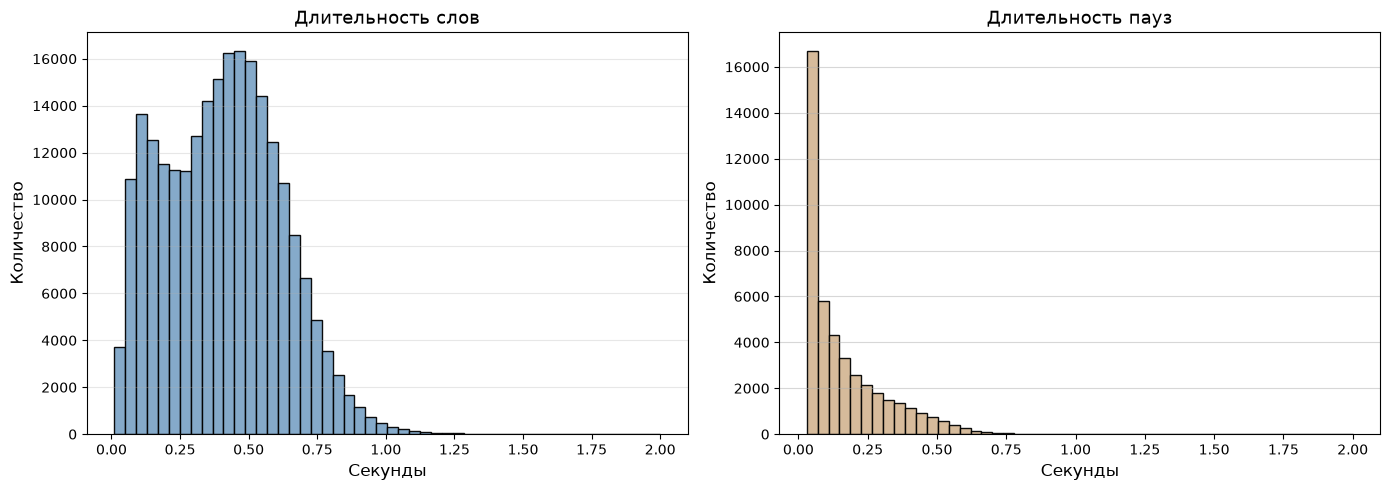

In [62]:
# Слова (только с буквами) и паузы
words = df[df['label'].astype(str).str.contains(r'[а-яё]', case=False, na=False, regex=True)]
pauses = df[df['is_pause_after'] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(words['duration'].clip(0, 2), bins=50, 
             color=COLOR_BLUE, edgecolor='black', alpha=0.95)
axes[0].set_title('Длительность слов', fontsize=13)
axes[0].set_xlabel('Секунды', fontsize=12)
axes[0].set_ylabel('Количество', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(pauses['pause_duration'].clip(0, 2), bins=50, 
             color=COLOR_BEIGE, edgecolor='black', alpha=0.95)
axes[1].set_title('Длительность пауз', fontsize=13)
axes[1].set_xlabel('Секунды', fontsize=12)
axes[1].set_ylabel('Количество', fontsize=12)
axes[1].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

In [63]:
print("Средние длительности:")
print(f"\nСлова:\n  средняя длительноссть = {words['duration'].mean():.3f} с, медиана = {words['duration'].median():.3f} с")
print(f"Пауза:\n  средняя длительноссть = {pauses['pause_duration'].mean():.3f} с, медиана = {pauses['pause_duration'].median():.3f} с")
print(f"\nМаксимум слова: {words['duration'].max():.2f} с")
print(f"Максимум паузы: {pauses['pause_duration'].max():.2f} с")

Средние длительности:

Слова:
  средняя длительноссть = 0.403 с, медиана = 0.410 с
Пауза:
  средняя длительноссть = 0.159 с, медиана = 0.100 с

Максимум слова: 2.98 с
Максимум паузы: 7.09 с


Большинство слов короче 1 секунды, а паузы имеют ярко выраженный пик в области до 100 мс.

### 2.3. Длительности фонем и гласных

In [64]:
phone_durations = []
vowel_durations = []

# Гласные в MFA-нотации
VOWELS = {'a', 'e', 'i', 'o', 'u', 'y', 'æ', 'ɨ', 'ə', 'ɛ', 'ɪ', 
          'a:', 'e:', 'i:', 'o:', 'u:', 'y:'}

ALIGN_DIR = '../../data/RUSLAN_align_v2/'
files = os.listdir(ALIGN_DIR)

for fname in tqdm(files, desc="Читаем TextGrid"):
    if not fname.endswith('.TextGrid'):
        continue
    try:
        tg = textgrid.openTextgrid(os.path.join(ALIGN_DIR, fname), True)
        phones = tg.getTier('phones')
        
        for entry in phones.entries:
            dur = entry.end - entry.start
            label = entry.label.strip()
            if not label or label in ('<SIL>', 'spn', 'sp'):
                continue
            
            phone_durations.append(dur)
            
            base = label.rstrip(':').replace('ː', '')
            if base in VOWELS:
                vowel_durations.append(dur)
    except Exception as e:
        continue

phone_durations = np.array(phone_durations)
vowel_durations = np.array(vowel_durations)

print("Длительности фонем (букв):")
print(f"  Всего фонем: {len(phone_durations)}")
print(f"  Средняя: {phone_durations.mean():.4f} с ({phone_durations.mean()*1000:.1f} мс)")
print(f"  Медиана: {np.median(phone_durations):.4f} с")

print(f"\nДлительности гласных:")
print(f"  Всего гласных: {len(vowel_durations)}")
print(f"  Средняя: {vowel_durations.mean():.4f} с ({vowel_durations.mean()*1000:.1f} мс)")
print(f"  Медиана: {np.median(vowel_durations):.4f} с")

Читаем TextGrid: 100%|██████████| 22199/22199 [00:21<00:00, 1028.37it/s]


Длительности фонем (букв):
  Всего фонем: 1423471
  Средняя: 0.0728 с (72.8 мс)
  Медиана: 0.0700 с

Длительности гласных:
  Всего гласных: 496742
  Средняя: 0.0552 с (55.2 мс)
  Медиана: 0.0500 с


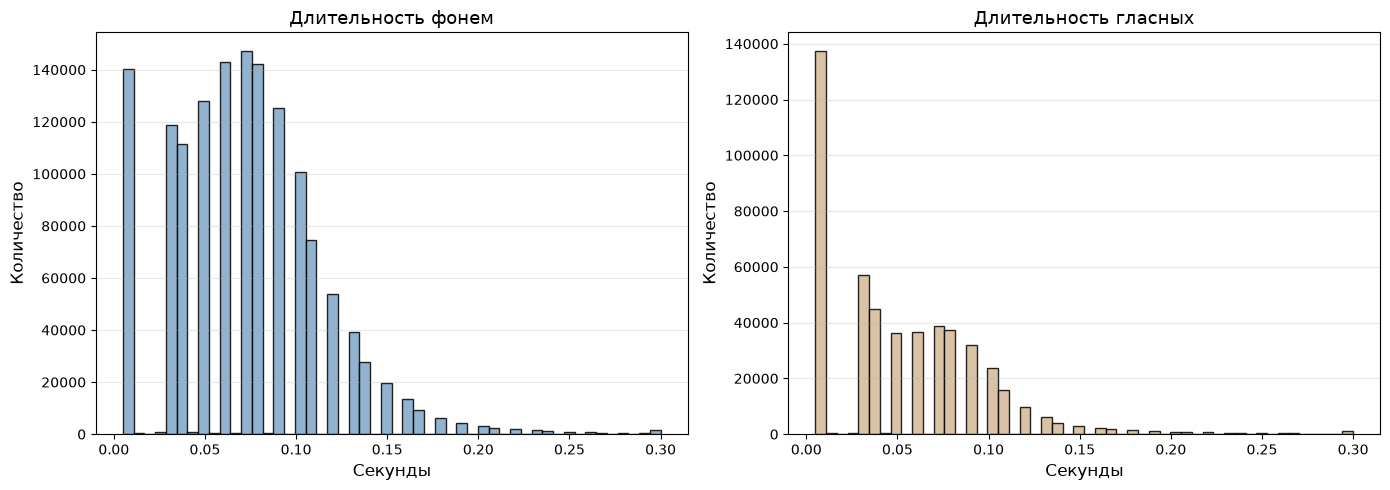

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(phone_durations.clip(0, 0.3), bins=50, 
             color=COLOR_BLUE, edgecolor='black', alpha=0.85)
axes[0].set_title('Длительность фонем', fontsize=13)
axes[0].set_xlabel('Секунды', fontsize=12)
axes[0].set_ylabel('Количество', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(vowel_durations.clip(0, 0.3), bins=50, 
             color=COLOR_BEIGE, edgecolor='black', alpha=0.85)
axes[1].set_title('Длительность гласных', fontsize=13)
axes[1].set_xlabel('Секунды', fontsize=12)
axes[1].set_ylabel('Количество', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Пример длительностей слов и фонем

In [66]:
fname = '../../data/RUSLAN_align_v2/000000_RUSLAN.TextGrid'
tg = textgrid.openTextgrid(fname, True)
tiers_names = tg.tierNames
print(f"Уровни: {tiers_names}")

words_tier = tg.getTier('words')
phones_tier = tg.getTier('phones')

print(f"\n Первые 5 слов:")
for e in words_tier.entries[:5]:
    print(f"  '{e.label}' [{e.start:.3f} - {e.end:.3f}]")

print(f"\n Первые 5 фонем:")
for e in phones_tier.entries[:5]:
    print(f"  '{e.label}' [{e.start:.3f} - {e.end:.3f}] ({e.end-e.start:.4f} с)")

Уровни: ('words', 'phones')

 Первые 5 слов:
  'с' [0.000 - 0.110]
  'тревожным' [0.110 - 0.690]
  'чувством' [0.690 - 1.310]
  'берусь' [1.310 - 1.700]
  'я' [1.700 - 1.790]

 Первые 5 фонем:
  's̪' [0.000 - 0.110] (0.1100 с)
  't̪' [0.110 - 0.180] (0.0700 с)
  'rʲ' [0.180 - 0.260] (0.0800 с)
  'ɪ' [0.260 - 0.270] (0.0100 с)
  'v' [0.270 - 0.360] (0.0900 с)


### 2.4. Паузы около знаков препинания (исключая последнее слово)

Проверим, как знаки препинания коррелируют с паузами.

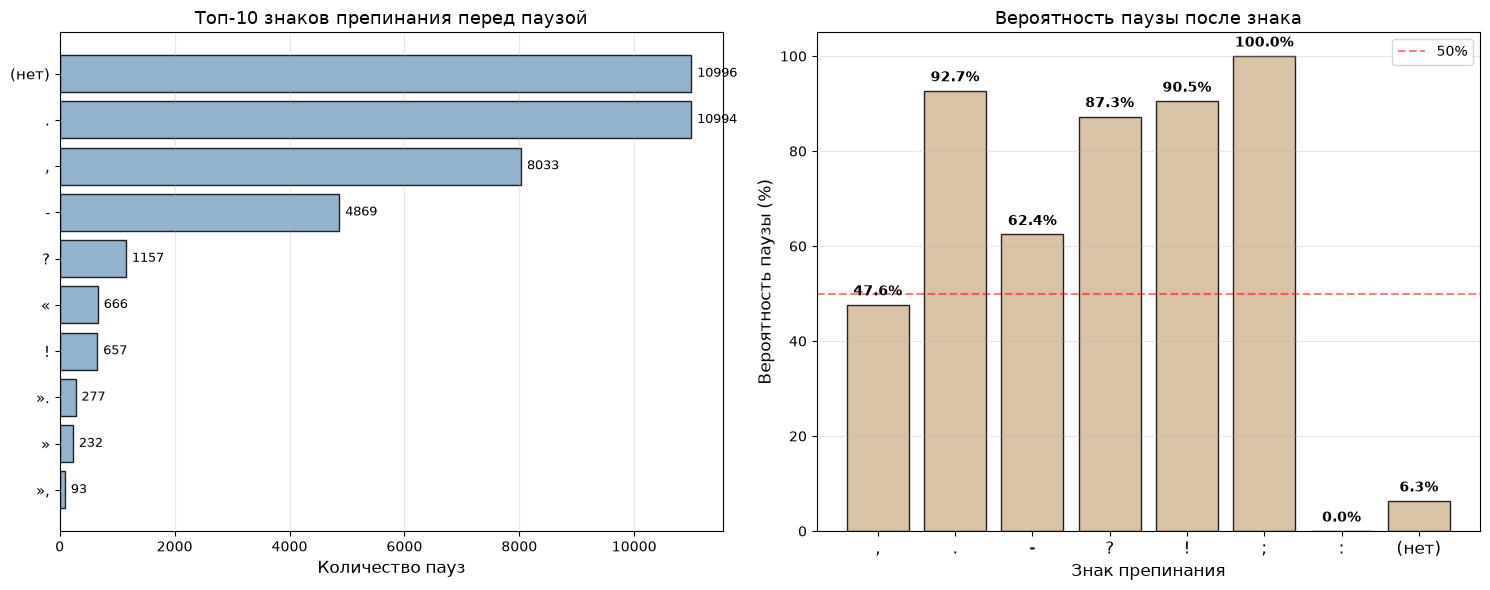

In [ ]:
df = df[df['is_last_word'] == 0].copy()

def last_punct(token):
    m = re.search(r'[.,!?;:—–\-«»""()]+$', str(token))
    return m.group(0) if m else '(нет)'

df['punct_after'] = df['label_raw'].apply(last_punct)

top_punct = df[df['is_pause_after'] == 1]['punct_after'].value_counts().head(10)

puncts = [',', '.', '-', '?', '!', ';', ':', '(нет)']
probs = []
for p in puncts:
    total = len(df[df['punct_after'] == p])
    with_pause = len(df[(df['punct_after'] == p) & (df['is_pause_after'] == 1)])
    probs.append(with_pause / total * 100 if total > 0 else 0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars1 = axes[0].barh(range(len(top_punct)), top_punct.values, 
                     color=COLOR_BLUE, edgecolor='black', alpha=0.85)
axes[0].set_yticks(range(len(top_punct)))
axes[0].set_yticklabels(top_punct.index, fontsize=11)
axes[0].invert_yaxis()
axes[0].set_xlabel('Количество пауз', fontsize=12)
axes[0].set_title('Топ-10 знаков препинания перед паузой', fontsize=13)
axes[0].grid(axis='x', alpha=0.3)

for bar, val in zip(bars1, top_punct.values):
    axes[0].text(val + 100, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=9)

bars2 = axes[1].bar(range(len(puncts)), probs, 
                    color=COLOR_BEIGE, edgecolor='black', alpha=0.85)
axes[1].set_xticks(range(len(puncts)))
axes[1].set_xticklabels(puncts, fontsize=12)
axes[1].set_ylabel('Вероятность паузы (%)', fontsize=12)
axes[1].set_xlabel('Знак препинания', fontsize=12)
axes[1].set_title('Вероятность паузы после знака', fontsize=13)
axes[1].axhline(50, color='red', linestyle='--', alpha=0.5, label='50%')
axes[1].set_ylim(0, 105)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

for bar, val in zip(bars2, probs):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 2,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.5. Классы пауз по длительности

Посмотрим распределение пауз по классам

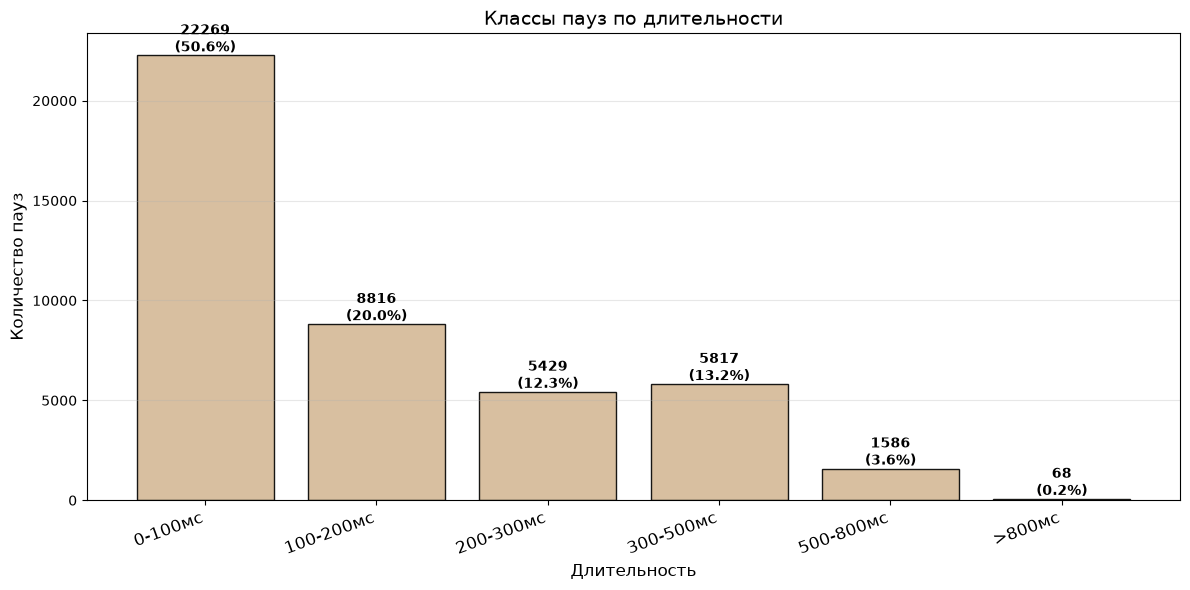

Классы пауз:
  0-100мс: 22269 (50.6%)
  100-200мс: 8816 (20.0%)
  200-300мс: 5429 (12.3%)
  300-500мс: 5817 (13.2%)
  500-800мс: 1586 (3.6%)
  >800мс: 68 (0.2%)


In [68]:
bins = [0, 0.1, 0.2, 0.3, 0.5, 0.8, 5.0]
labels = ['0-100мс', '100-200мс', '200-300мс', '300-500мс', '500-800мс', '>800мс']

pauses['bin'] = pd.cut(pauses['pause_duration'], bins=bins, labels=labels)
bin_counts = pauses['bin'].value_counts().sort_index()
bin_pct = (bin_counts / bin_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(range(len(bin_counts)), bin_counts.values,
              color=COLOR_BEIGE, edgecolor='black', alpha=0.9)

ax.set_xticks(range(len(bin_counts)))
ax.set_xticklabels(bin_counts.index, rotation=20, ha='right', fontsize=12)
ax.set_ylabel('Количество пауз', fontsize=12)
ax.set_xlabel('Длительность', fontsize=12)
ax.set_title('Классы пауз по длительности', fontsize=14)
ax.grid(axis='y', alpha=0.3)

for bar, count, pct in zip(bars, bin_counts.values, bin_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count}\n({pct}%)', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Классы пауз:")
for label, count, pct in zip(bin_counts.index, bin_counts.values, bin_pct.values):
    print(f"  {label}: {count} ({pct}%)")

### 2.6. Выводы по разведочному анализу

**Общая статистика:**
- Всего токенов: **234016**, уникальных предложений **19389** (88% корпуса RUSLAN)
- Разбиение train/test — **80/20** (детерминированное)
- **Дисбаланс классов:** 18.80% слов с паузой, 81.20% без паузы

**Длительности:**
|  | Средняя | Медиана |
|--------|---------|---------|
| Слово | 0.403 с | 0.410 с |
| Пауза | 0.159 с | 0.100 с |
| Фонема | 0.073 с | 0.070 с |
| Гласная | 0.055 с | 0.050 с |



**Наиболее частые паузы около знаков препинания:**
- **Точка `.`** - 92,7%
- **Восклицательный знак `!`** - 90,5%
- **Вопросительный знак `?`**- 87,3%
- **Тире `-`** - 62,4%

**Классы пауз:**
| Класс | Доля |
|-------|------|
| **0–100 мс** (микропаузы) | **50.6%** |
| 100–200 мс (воспринимаемые) | 20.0% |
| 200–300 мс (короткие) | 12.3% |
| 300–500 мс (средние) | 13.2% |
| 500–800 мс (длинные) | 3.6% |
| >800 мс (очень длинные) | 0.2% |

**Анализ результатов EDA:**
1. Большинство пауз <100 мс - микропаузы на стыках слов, которые не воспринимаются на слух как паузы;
2. Знаки препинания сильно коррелируют с паузами;
3. Дисбаланс классов необходимо учесть в классификаторе.

#### Фильтрация токенов
- Некоторые токены плохо выровнены (MFA-ошибки);
- Токены с аномально длинными фонемами (>0.5 с);
- Короткие паузы (<30 мс) при обучении.

#### Фильтрация пауз
- Исключить финальные SIL >800 мс;
- Учесть дисбаланс классов (18.80% / 81.20%);
- Порог минимальной паузы, чтобы микропаузы не входили.

#### Шумоочистка (отфильтровывает 11.56% шумов)
Убрать предложения:
- <3 слов;
- с плотностью пауз >40%;

#### POS-фичи
- spaCy: предыдущее и следующее слова + расстояния до пунктуации

#### Правило постановки паузы
- Пауза около знаков `.` `!` `?`
- Пауза около `-`, если модель колеблется

### 2.7. Анализ качества сегментации

In [69]:
meta = pd.read_csv('../../data/metadata_RUSLAN_22200_normalized.csv', 
                   sep='|', names=['id', 'raw', 'nrm'], quoting=csv.QUOTE_NONE)
print(f"Всего в метаданных: {len(meta)}")
print(f"Уникальных id: {meta['id'].nunique()}")

df = pd.read_csv('data/RUSLAN_pause_metadata.csv', sep='|', quoting=csv.QUOTE_NONE)
print(f"\nВсего токенов в подготовленных данных: {len(df)}")
print(f"Уникальных utterances (id): {df['id'].nunique()}")

lost = set(meta['id']) - set(df['id'])
print(f"\nПотеряно utterances: {len(lost)} ({len(lost)/len(meta)*100:.2f}%)")

Всего в метаданных: 21923
Уникальных id: 21923

Всего токенов в подготовленных данных: 234016
Уникальных utterances (id): 19389

Потеряно utterances: 2534 (11.56%)


| Этап | Utterances | Доля |
|---|---|---|
| Исходные метаданные | 21 923 | 100% |
| Сохранено в `RUSLAN_pause_metadata.csv` | 19 389 | **88.44%** |
| Отфильтровано как шумные | 2534 | **11.56%** |

**Выводы:**
- 2534 - потери после фильтрации;
- Основные классы ошибок: частичное выравнивание (пропущена часть слов), несовпадение текста и аудио, слишком длинные паузы (`022190` — SIL 4.688 с).

## 3. Предиктор пауз

In [70]:
proc = subprocess.Popen(
    [sys.executable, '-u', 'pause_predictor.py'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1, cwd='.'
)

SKIP = re.compile(r'^\s*\S+:\s+\d+%\|')
for line in proc.stdout:
    if SKIP.match(line):
        continue
    if line.strip():
        print(line, end='')
proc.wait()

if proc.returncode != 0:
    raise RuntimeError(f'pause_predictor.py failed with code {proc.returncode}')

[spaCy] ru_core_news_sm loaded (parser/ner/lemmatizer disabled)
Loading weights: 100%|██████████| 55/55 [00:00<00:00, 5410.10it/s]
[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[fit] build train dataset...
epoch 1/4, loss 4.1175, val_f1 0.7142
epoch 2/4, loss 3.5730, val_f1 0.7228
epoch 3/4, loss 3

## Итог

Было протестировано 4 модели:
1) rubert-tiny2 + BiLSTM + CRF
2) rubert-base-cased + BiLSTM
3) rubert-base-cased без LSTM
4) CatBoost

Наилучший результат продемонстрировала **rubert-tiny2 + BiLSTM + CRF**, поэтому была взята за основу.

| Конфигурация | F1 test | MAE |
|---|---|---|
| rubert-base-cased без LSTM | 0.6805 | 0.111 |
| rubert-base-cased с LSTM | плато около 68% на обучении, в связи с чем тест не досчитан, эксперимент не закончен | — |
| CatBoost (с POS) | 0.6885 | 0.114 |
| rubert-tiny2 + LSTM + CRF | 0.7180 | 0.116 |
| **rubert-tiny2 + LSTM + CRF + POS + пост-процессинг** | **0.7229** | **0.1160** |

### Архитектура

`rubert-tiny2 + BiLSTM + CRF + регрессор + пост-процессинг`

| Компонент | Описание |
|---|---|
| rubert-tiny2 | 312-dim, fine-tuned, контекстные эмбеддинги |
| Hand-crafted фичи | 65-dim: пунктуация, POS, расстояния |
| BiLSTM | hidden=128, последовательный контекст |
| CRF | 2 класса, учёт переходов |
| Регрессор | Linear -> 1, длительность в log-space |
| Dropout | 0.3, регуляризация |
| Пост-процессинг | правила для `.!?` и дефиса |

### Использованные фичи

- **Пунктуация** (8): `, . — - ? ! ; :`
- **Базовые** (6): `rel_pos`, `len_norm`, `is_conj`, `is_part`, `is_final`, `prev_punct_any`
- **POS текущего слова** (16): one-hot
- **POS предыдущего слова** (16): one-hot
- **POS следующего слова** (16): one-hot
- **Расстояния до пунктуации** (2): до предыдущей и следующей, нормированные на 10
- **Длина предложения** (1): нормирование на 40

### Возможные причины такого результата

- **50% пауз короче 100 мс** - микро-задержки MFA, не реальные паузы (однако при фильтрации пауз <100 мс. результат не улучшается);
- **82% ложнопропущенных пауз (FN) не имеют пунктуации** в тексте;
- Частичное несоответствие разметки на сырых и нормализованных данных.

### Возможные пути преодоления
- Смена MFA на более сильный метод автоматической разметки.
- Ручная корректировка разметки: выявление несоответствий между текстом и озвучиванием.